In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import osmnx as ox
import requests
import zipfile
import contextily as ctx
from shapely.geometry import Point
from PIL import Image
from io import BytesIO
import math
import rasterio 


import os
import tempfile
import requests

c:\Users\A02470076\AppData\Local\miniconda3\envs\killme\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
#MAP DATA#

maps_dir = "Maps"

def load_local_map_layer(zip_name):
    layer_dir = tempfile.mkdtemp()
    zip_path = os.path.join(maps_dir, zip_name)
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(layer_dir)
    shapefile = next(
        os.path.join(layer_dir, name)
        for name in os.listdir(layer_dir)
        if name.endswith(".shp")
    )
    return gpd.read_file(shapefile)

rivers = load_local_map_layer("ne_10m_rivers_north_america.zip")
countries = load_local_map_layer("ne_10m_admin_0_countries.zip")
lakes = load_local_map_layer("ne_10m_lakes.zip")
urbanareas = load_local_map_layer("ne_10m_urban_areas.zip")

# No matching local ZIPs are present for these optional layers.
oceans = None
parks = None
state_borders = countries.copy()

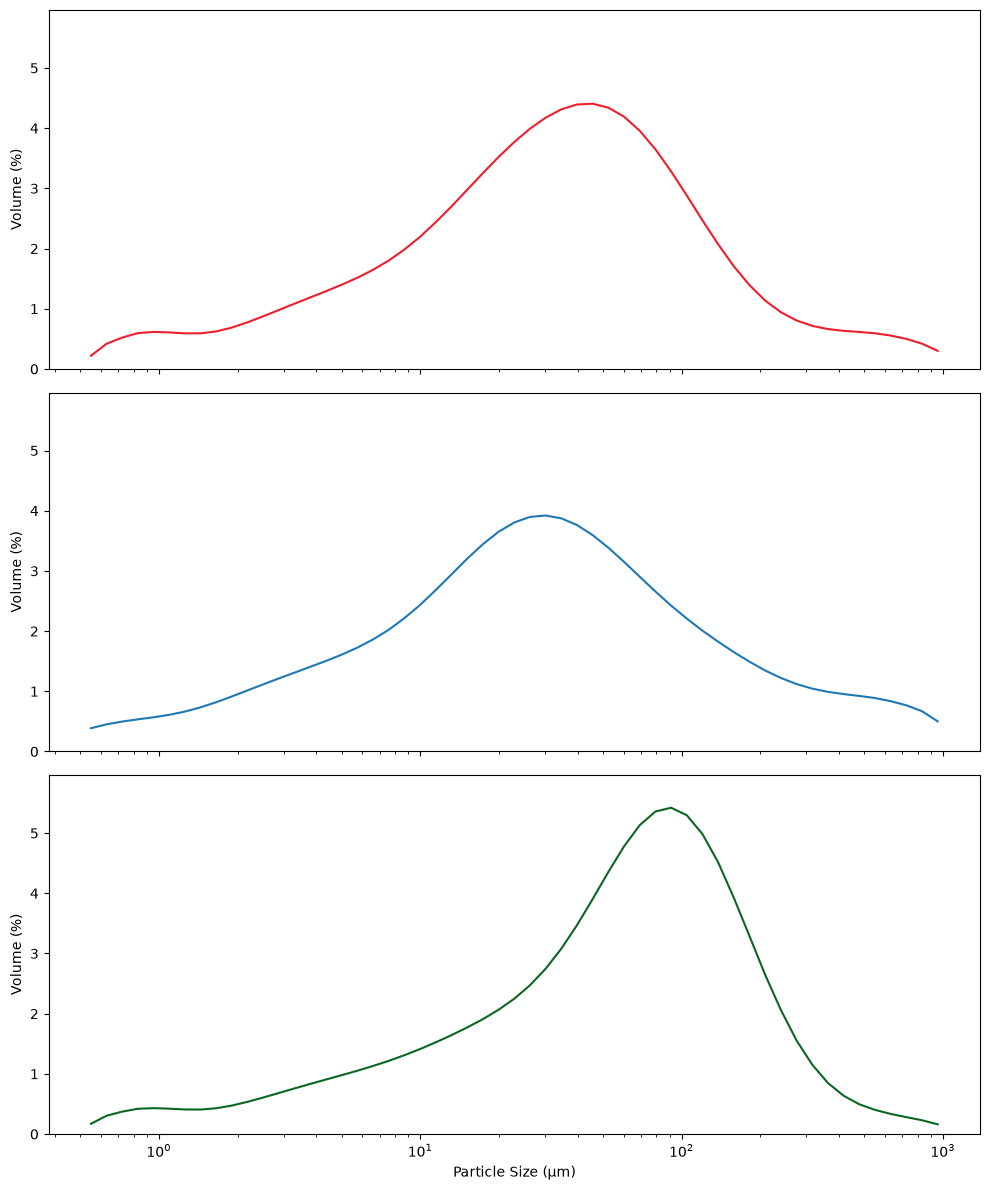

In [4]:
# Load the file
file_name = "Malvern Data/2026_SedStrat_MalvernData.xlsx"
df = pd.read_excel(file_name)

# Extract bins and valid columns
bin_sizes_row = df.iloc[0]
distribution_cols = df.iloc[:, 58:113]

size_bins = []
valid_cols = []
for col in distribution_cols:
    val = bin_sizes_row[col]
    if pd.notna(val) and isinstance(val, (int, float)):
        size_bins.append(float(val))
        valid_cols.append(col)

# Filter average rows
avg_rows = df[df['Sample Name'].astype(str).str.contains('Group', case=False, na=False)].copy()

# Determine global max volume for consistent y-axes
max_vol = 0
plot_data = []
for index, row in avg_rows.iterrows():
    sample_name = row['Sample Name']
    volumes = pd.to_numeric(row[valid_cols], errors='coerce').fillna(0).values
    max_vol = max(max_vol, volumes.max())
    plot_data.append((sample_name, volumes))

# Create subplots
fig, axes = plt.subplots(nrows=len(plot_data), ncols=1, figsize=(10, 12), sharex=True)

colors = ['#f01e2c', '#1f77b4', '#0B6623'] 

for i, (sample_name, volumes) in enumerate(plot_data):
    ax = axes[i]
    ax.plot(size_bins, volumes, marker='', color=colors[i % len(colors)])
    # ax.set_title(sample_name)
    ax.set_ylabel('Volume (%)')
    ax.set_ylim(0, max_vol * 1.1) 
    # Grid lines removed!

# X-axis formatting on the bottom subplot
axes[-1].set_xscale('log')
axes[-1].set_xlabel('Particle Size (µm)')

plt.tight_layout()
plt.savefig('Visualizations/grain_size_subplots_nogrid.svg', dpi=300)
plt.show()

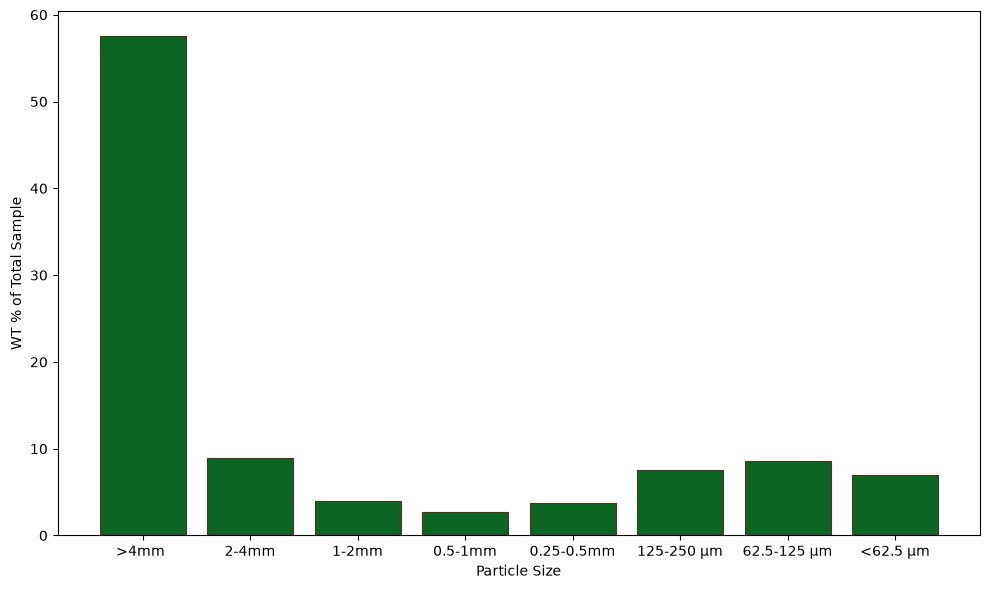

,Particle size,Weight (g),Weight (%)
0,>4mm,563.2,57.569253
1,2-4mm,87.6,8.954308
2,1-2mm,38.9,3.976285
3,0.5-1mm,26.1,2.667893
4,0.25-0.5mm,36.4,3.720740
5,125-250 µm,74.0,7.564142
6,62.5-125 µm,84.2,8.606767
7,<62.5 µm,67.9,6.940611


In [5]:
# Load sieve-size classes and retained weights
file_name = "Sieve Data/Sieving Data.xlsx"
sieve_df = pd.read_excel(file_name, usecols="B,D")
sieve_df.columns = ["Particle size", "Weight (g)"]
sieve_df = sieve_df.dropna(subset=["Particle size", "Weight (g)"])
sieve_df["Weight (g)"] = pd.to_numeric(sieve_df["Weight (g)"], errors="coerce")
sieve_df = sieve_df.dropna(subset=["Weight (g)"])

# Calculate the percentage of the sample retained in each size class
sieve_df["Weight (%)"] = sieve_df["Weight (g)"] / sieve_df["Weight (g)"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(sieve_df))
ax.bar(
    positions,
    sieve_df["Weight (%)"],
    width=0.8,
    color="#0B6623",
    edgecolor="#542f22",
    linewidth=0.8,
)
ax.set_xticks(positions, sieve_df["Particle size"])
ax.set_xlabel("Particle Size")
ax.set_ylabel("WT % of Total Sample")
#ax.set_title("Grain Size Distribution from Sieving")
ax.grid(False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("Visualizations/grain_size_histogram.svg", dpi=300)
plt.show()

sieve_df

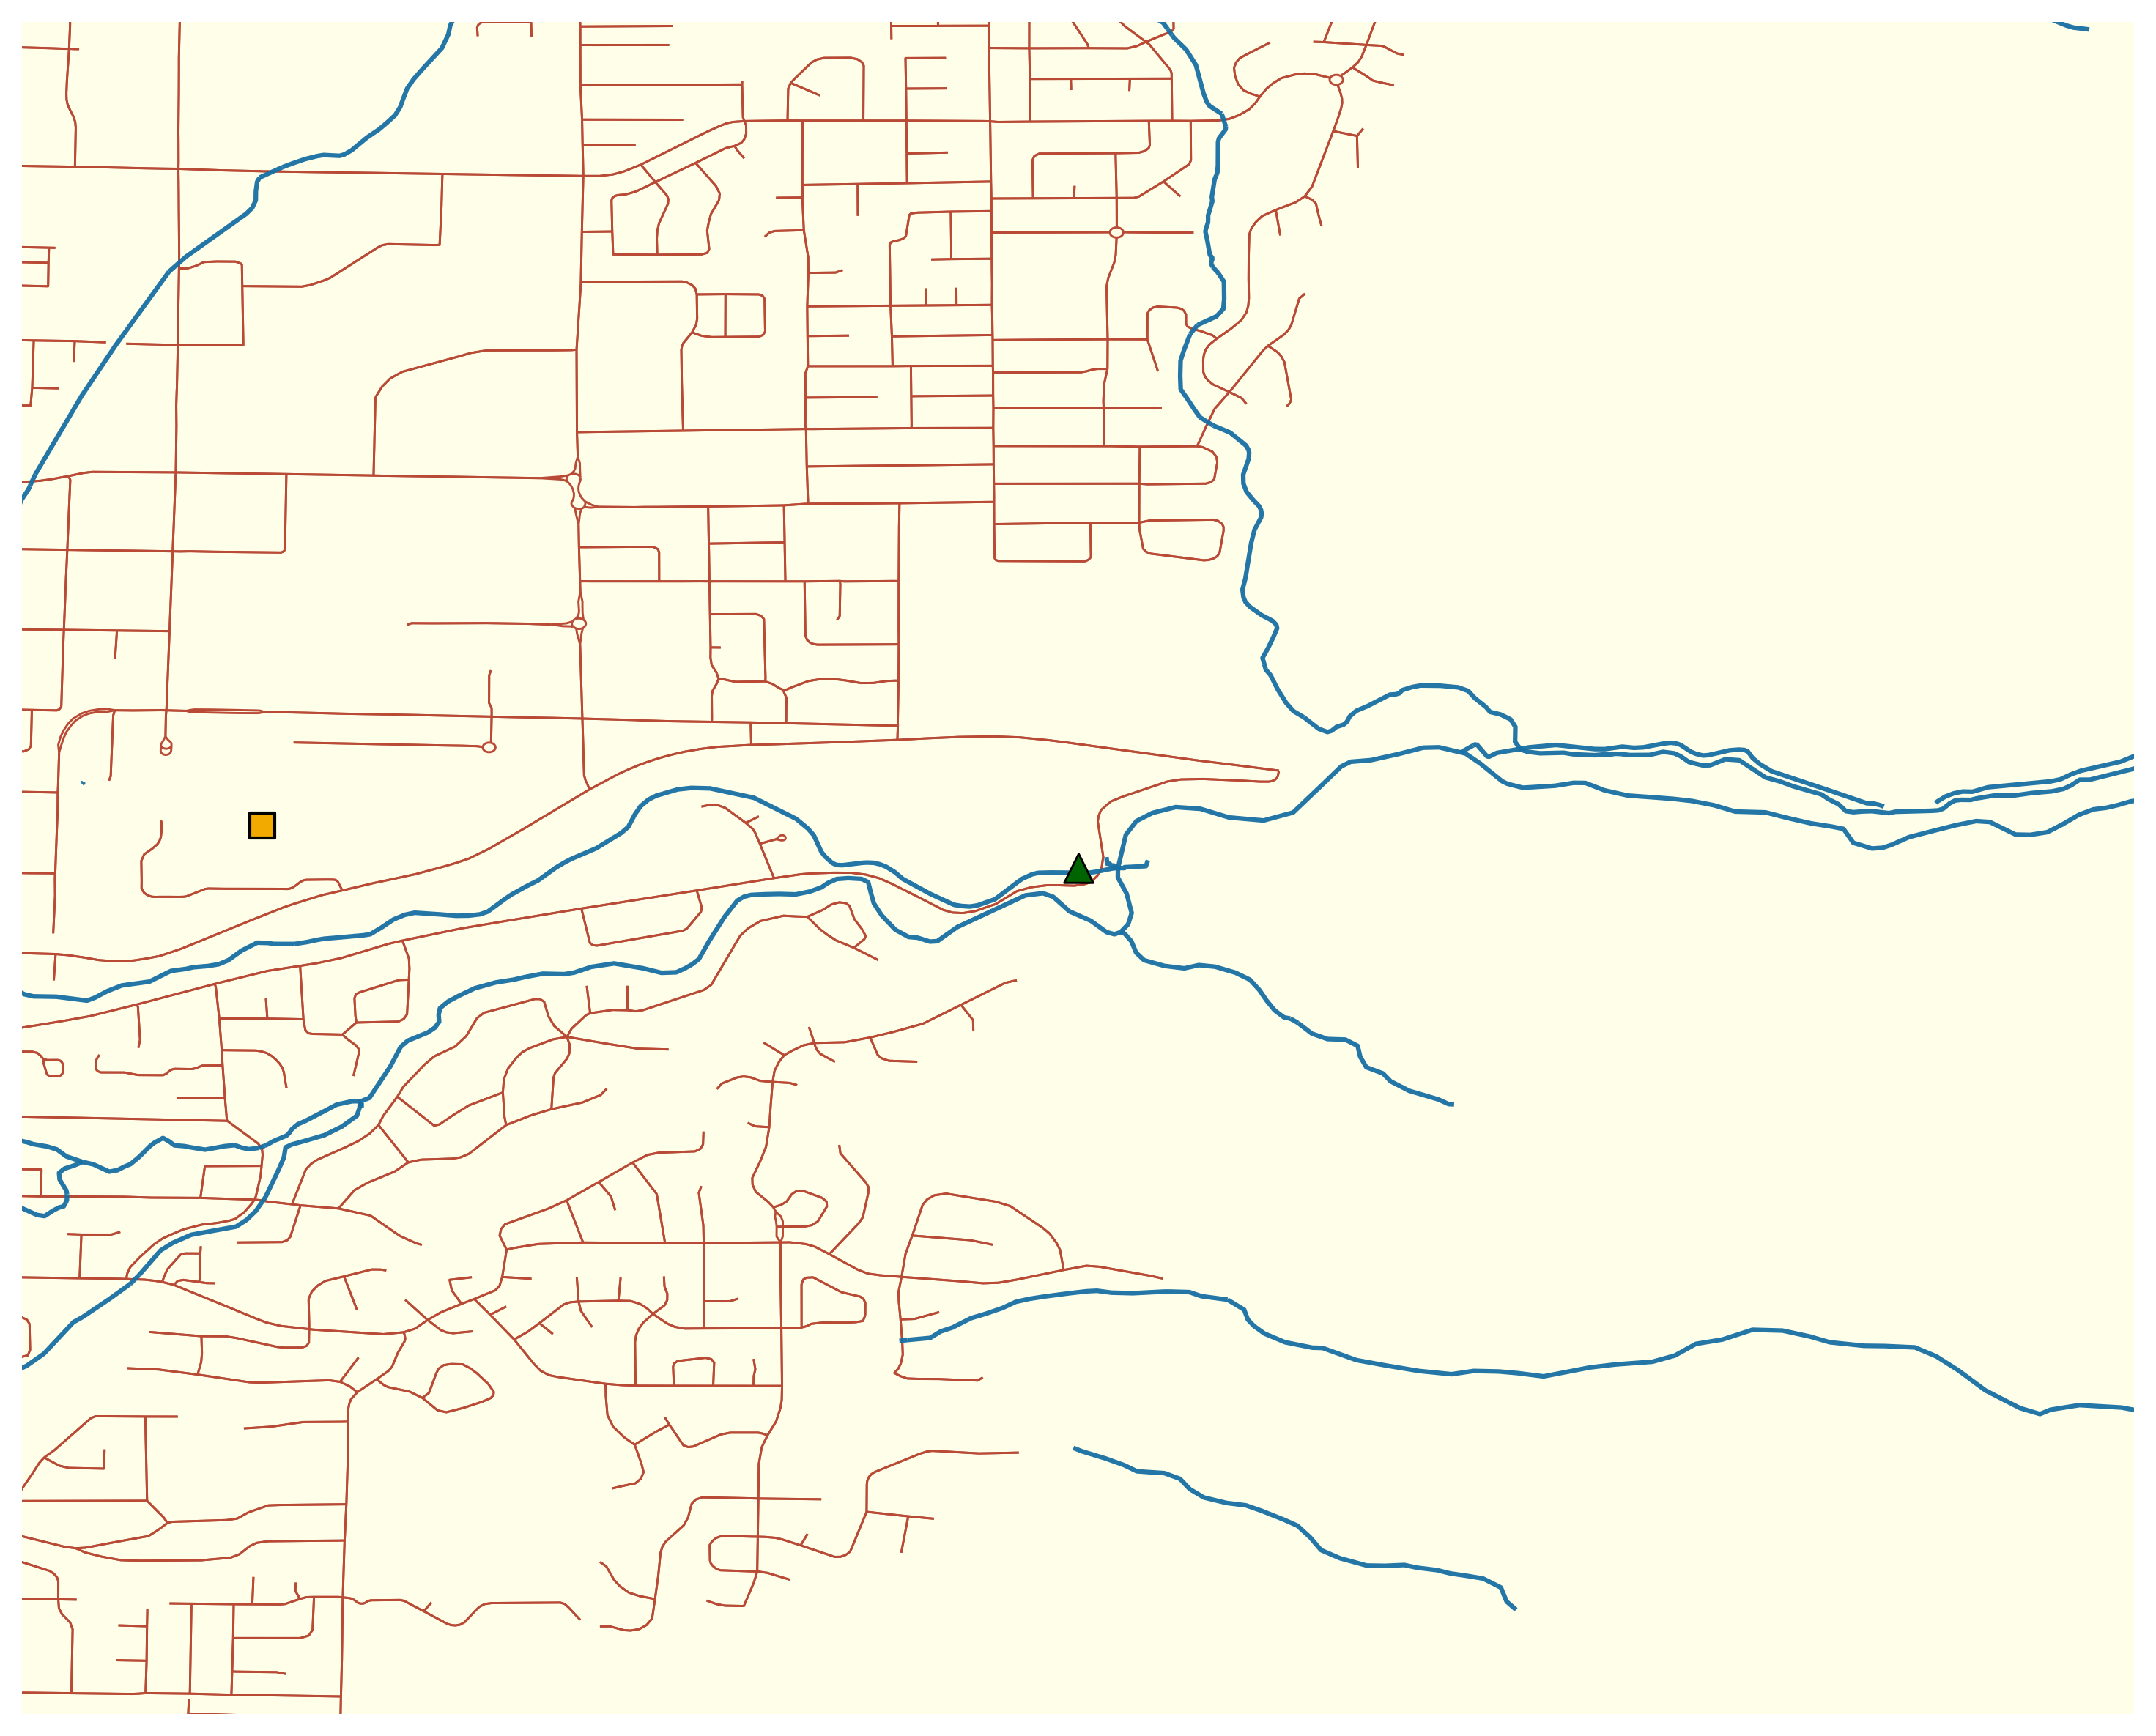

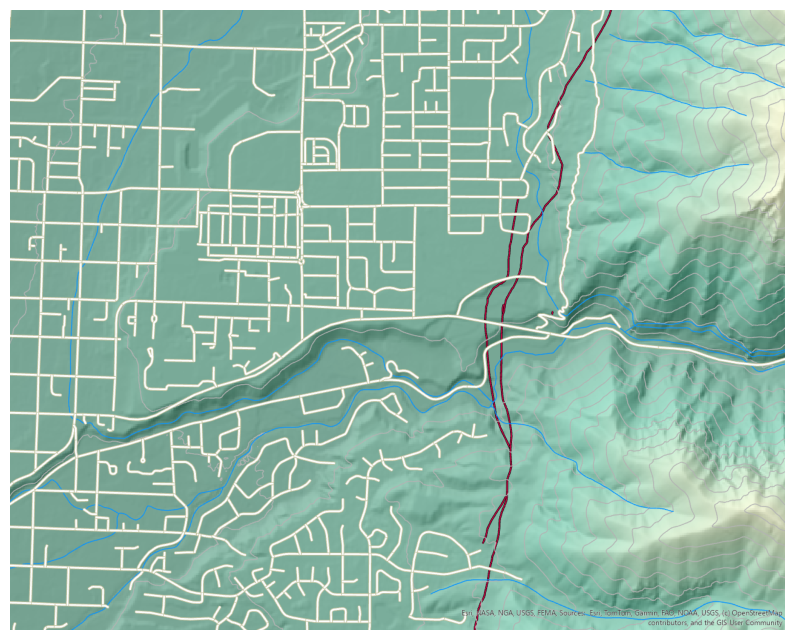

In [17]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# 1. Open the GeoTIFF file
tif_path = "Maps/Map.tif"
with rasterio.open(tif_path) as src:
    
    # 2. Set up the matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))

    image_plot = show(src, ax=ax, cmap="terrain") # 'cmap' adjusts the color palette

    ax.set_axis_off()  # Turn off axis labels and ticks
    plt.show()